<a href="https://colab.research.google.com/github/maazali04/deep-learning-campusx/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptron

- an algorithm used for supervised machine learning and acts as a building block of deep learning.

- Note: Step function as an activation function to decide whether a neuron should fire or stay off. If the input total passes a certian threshold, the step funciton outputs 1 (active). If it falls below, it outputs 0 (inactive).

- An activation function is a mathematical formula applied to a neuron's output in an artificial neural network. It determines whether the neuron should fire (activate) and how strong its signal should be based on its input. e.g. ReLU (max(0,x)) , Sigmoid (0 or 1) or tanh (-1,1).

```
Inputs          Weights       Summation          Activation     Loss Function       Output
                               Junction           Function

  x₁ ----------> [ w₁ ] ---------\
                                  \
  x₂ ----------> [ w₂ ] -----------> [ ∑ wᵢxᵢ + b ] ---> [ f(x) ] ---> Loss Function ---> Final Output (y)
                                  /
  ... ---------> [ ... ]        /
                               /
  Bias (1) ----> [  b  ] -----/
```

Note: The Perceptron class in sklearn.linear_model is based on the original 1957 Rosenblatt Perceptron, not a modern Artificial Neural Network

| Loss Function | Activation Function| Output |
| --- | --- | ---|
|Hinge Loss | Step | Perceptron (binary classifier (-1,+1))|
|Log-loss (binary cross entropy) | Sigmoid | Logistic Regression (binary classifier (0,1))|
|Categorical Cross Entropy | Softmax | Logistic Regression (multi-class classifier)|
|mse|linear| Linear Regression|

## Mathematical Walkthrough

| Point | Input x1 | Input x2 | Target (y) |
|---|----|---|---|
|$P_1$|$0$|$0$|$0$|
|$P_2$|$0$|$1$|$0$|
|$P_3$|$1$|$0$|$0$|
|$P_4$|$1$|$1$|$1$|


**Initial Parameters:**
- Initial Weights: $w_1 = 0.0$, $w_2 = 0.0$
- Initial Bias: $b = 0.0$
- Learning Rate ($\eta$): $0.1$
- Step Function ($\text{Step}(z)$):
  - If $z \ge 0 \rightarrow 1$
  - If $z < 0 \rightarrow 0$

**Epoches**

**Epoch 1**

An "Epoch" means passing through all 4 dataset points once.

The formulas used at every step are:
1. $z = (w_1 \cdot x_1) + (w_2 \cdot x_2) + b$
2. $\hat{y} = \text{Step}(z)$
3. $\text{Error} = y - \hat{y}$
4. $w_1 \leftarrow w_1 + (\eta \cdot \text{Error} \cdot x_1)$
5. $w_2 \leftarrow w_2 + (\eta \cdot \text{Error} \cdot x_2)$
6. $b \leftarrow b + (\eta \cdot \text{Error})$

**Point 1: $x_1 = 0, x_2 = 0 \longrightarrow$ Target $y = 0$**
$$z = (0.0 \cdot 0) + (0.0 \cdot 0) + 0.0 = 0.0$$
Since $z = 0 \ge 0 \rightarrow \hat{y} = 1$
$$\text{Error} = 0 - 1 = \mathbf{-1} \quad \text{(Mistake!)}$$

**Update Weights & Bias**

$w_1 = 0.0 + (0.1 \cdot -1 \cdot 0) = \mathbf{0.0}$

$w_2 = 0.0 + (0.1 \cdot -1 \cdot 0) = \mathbf{0.0}$

$b = 0.0 + (0.1 \cdot -1) = \mathbf{-0.1}$

New State: $w_1 = 0.0, \quad w_2 = 0.0, \quad b = -0.1$


**Point 2: $x_1 = 0, x_2 = 1 \longrightarrow$ Target $y = 0$**

$$z = (0.0 \cdot 0) + (0.0 \cdot 1) + (-0.1) = -0.1$$

Since $z = -0.1 < 0 \rightarrow \hat{y} = 0$

$$\text{Error} = 0 - 0 = \mathbf{0} \quad \text{(Correct!)}$$

No error means no changes made to $w_1, w_2, b$.

New State: $w_1 = 0.0, \quad w_2 = 0.0, \quad b = -0.1$


**Point 3: $x_1 = 1, x_2 = 0 \longrightarrow$ Target $y = 0$**
$$z = (0.0 \cdot 1) + (0.0 \cdot 0) + (-0.1) = -0.1$$
Since $z = -0.1 < 0 \rightarrow \hat{y} = 0$
$$\text{Error} = 0 - 0 = \mathbf{0} \quad \text{(Correct!)}$$

New State: $w_1 = 0.0, \quad w_2 = 0.0, \quad b = -0.1$

**Point 4: $x_1 = 1, x_2 = 1 \longrightarrow$ Target $y = 1$**
$$z = (0.0 \cdot 1) + (0.0 \cdot 1) + (-0.1) = -0.1$$

Since $z = -0.1 < 0 \rightarrow \hat{y} = 0$

$$\text{Error} = 1 - 0 = \mathbf{+1} \quad \text{(Mistake!)}$$

Update Weights & Bias:

$w_1 = 0.0 + (0.1 \cdot 1 \cdot 1) = \mathbf{0.1}$

$w_2 = 0.0 + (0.1 \cdot 1 \cdot 1) = \mathbf{0.1}$

$b = -0.1 + (0.1 \cdot 1) = \mathbf{0.0}$

End of Epoch 1 State: $w_1 = 0.1, \quad w_2 = 0.1, \quad b = 0.0$

It takes the latest, updated weight and bias values from the end of Point 4! an start testing all four points again until it finds the mistake 0.


In [ ]:
import numpy as np

class MyPerceptron:

    def __init__(self, epochs, alpha=0.1):
        self.epochs = epochs
        self.alpha = alpha
        self.weights = None
        self.bias = 0

    def step(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            z = X @ self.weights + self.bias
            y_hat = self.step(z)
            error = y - y_hat
            if np.all(error == 0):
                break
            self.weights += self.alpha * (X.T @ error)
            self.bias += self.alpha * error.sum()
            print(self.weights, self.bias)
        return self

    def predict(self, X):
        z = X @ self.weights + self.bias
        return self.step(z)


In [ ]:
import numpy as np
import pandas as pd


X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])


model = MyPerceptron(epochs=20, alpha=0.1)
model.fit(X, y)

predictions = model.predict(X)

print("\n--- Final Results ---")
print("Target Output:     ", y)
print("Model Predictions: ", predictions)
print("Final Weights:     ", model.weights)
print("Final Bias:        ", model.bias)


[-0.1 -0.1] -0.30000000000000004
[0. 0.] -0.20000000000000004
[0.1 0.1] -0.10000000000000003

--- Final Results ---
Target Output:      [0 0 0 1]
Model Predictions:  [0 0 0 1]
Final Weights:      [0.1 0.1]
Final Bias:         -0.10000000000000003


<Axes: >

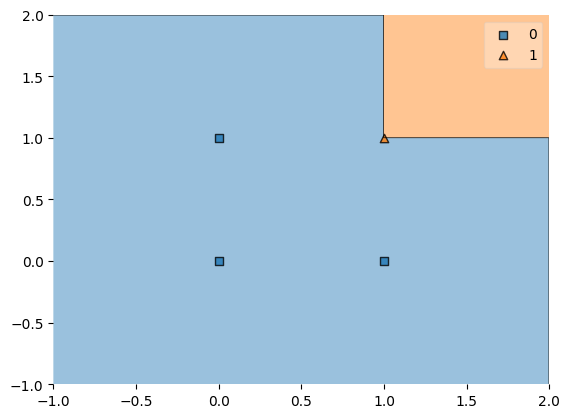

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y, clf=p, legend=1)

In [ ]:
import pandas as pd
from sklearn.linear_model import Perceptron
p = Perceptron()

X = pd.DataFrame([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

p.fit(X,y)
p.coef_, p.intercept_

(array([[2., 2.]]), array([-2.]))

<Axes: >

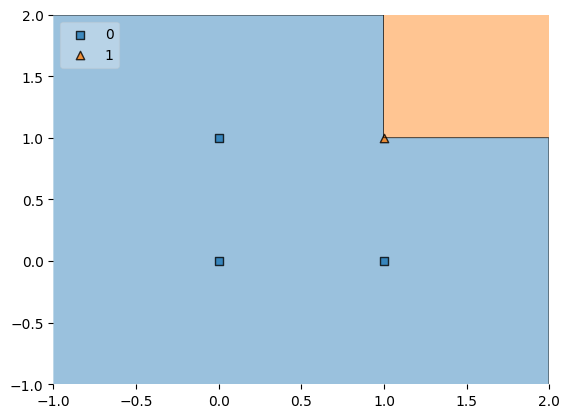

In [ ]:
plot_decision_regions(X.values, y, clf=p, legend=2)

## Hinge Loss
- Hinge loss is a loss function used for training classifiers, mostly support vector machines (SVMs).
-  It penalizes wrong predictions and points that are too close to the decision boundary, encouraging a clear margin of separation between different classes.

$$\text{Loss}=\max (0,1-y\cdot y^{\prime })$$

Here y = [-1,+1]

Now we need loss function to correctly classify the point and draw a decision boundry line.

**Perceptron Loss (Sklean) (Hinge Loss Variant)**
$$L(w_1,w_2,b) = \frac 1 n \sum_{i=1}^n L (0, y_i f(x_i)) + \alpha R(w_1,w_2)$$
$$ L(0, y_i f(x_i)) = max(0, -y_if(x_i))$$
$$f(x_i) = z$$

**Numerical Example**
|Situation|True Label (y)|Raw Score (z)|Product (y⋅z)|Classification|
|---|---|---|---|---|
|Positive point, correct side|$+1$|$+2.5$|$+2.5 > 0$|Correct|
|Negative point, correct side|$-1$|$-1.8$|$+1.8 > 0$|Correct|
|Positive point, wrong side|$+1$|$-3.0$|$-3.0 < 0$|Misclassified|
|Negative point, wrong side|$-1$|$+1.2$|$-1.2 < 0$|Misclassified|

Key Rule: If $y \cdot z \ge 0$, the point is correctly classified. If $y \cdot z < 0$, it is misclassified, and the magnitude $\vert{}y \cdot z\vert{}$ tells you how far away it is from the boundary line!

Difference between Hinge loss and Perceptron loss

* Perceptron Loss:  max(0,  -y * z)     -->  Penalty starts right at the line (z = 0)
* Hinge Loss (SVM): max(0, 1 - y * z)   -->  Penalty starts inside a safety margin (z = 1)

**Gradient**

$$L(\mathbf{w}, b) = -\sum_{i \in \text{Misclassified}} y_i (\mathbf{w}^T \mathbf{x}_i + b)$$

$$L_i = -y_i (\mathbf{w}^T \mathbf{x}_i + b)$$
$$\frac{\partial L_i}{\partial \mathbf{w}} = -y_i \mathbf{x}_i$$

$$\frac{\partial L_i}{\partial \mathbf{w}} = \begin{cases} \mathbf{0} & \text{if } y_i (\mathbf{w}^T \mathbf{x}_i + b) \ge 0 \quad \text{(Correct)} \\ -y_i \mathbf{x}_i & \text{if } y_i (\mathbf{w}^T \mathbf{x}_i + b) < 0 \quad \text{(Misclassified)} \end{cases}$$

&nbsp;

$$\frac{\partial L_i}{\partial b} = \begin{cases} 0 & \text{if } y_i (\mathbf{w}^T \mathbf{x}_i + b) \ge 0 \quad \text{(Correct)} \\ -y_i & \text{if } y_i (\mathbf{w}^T \mathbf{x}_i + b) < 0 \quad \text{(Misclassified)} \end{cases}$$

OR

Now perform a standard Gradient Descent update ($\mathbf{w}_{new} = \mathbf{w}_{old} - \alpha \frac{\partial L}{\partial \mathbf{w}}$):

$$\mathbf{w}_{new} = \mathbf{w}_{old} - \alpha (-y_i \mathbf{x}_i) = \mathbf{w}_{old} + \alpha \cdot y_i \cdot \mathbf{x}_i$$

## Problem with Perceptron
It only works with linear data and can't handle non-linear data.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron

X = pd.DataFrame([[0, 0], [0, 1], [1, 0], [1, 1]])

y = np.array([0, 1, 1, 0])  # True XOR

p = Perceptron(max_iter=1000)
p.fit(X, y)

print("Predictions:", p.predict(X))
print("Accuracy:", p.score(X, y))

Predictions: [0 0 0 0]
Accuracy: 0.5


<Axes: >

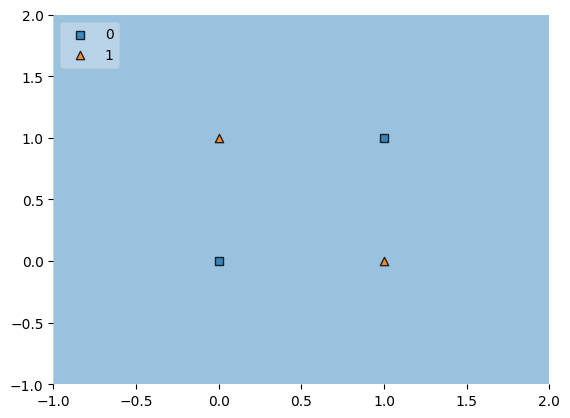

In [ ]:
plot_decision_regions(X.values, y, clf=p, legend=2)

## How Multilayer Perceptron  (MLP) solves this problem?

Before it lets understand MLP.

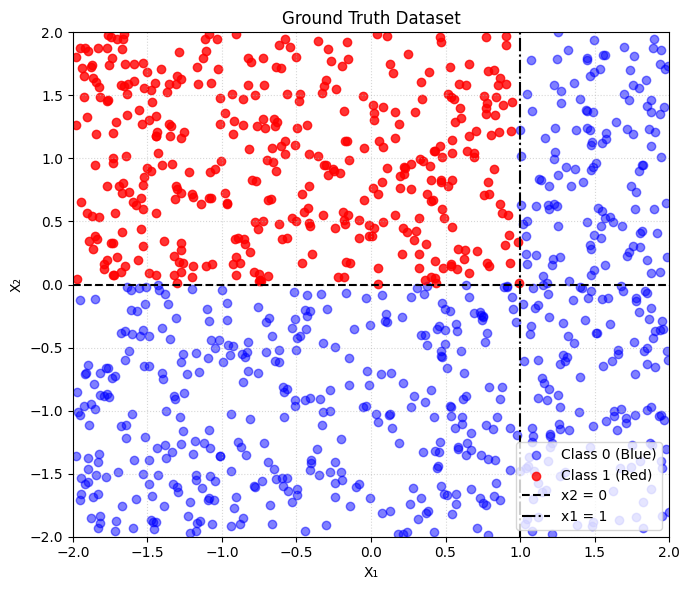

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n_samples = 1000

# Generate 2D points in [-2, 2] x [-2, 2]
X = np.random.uniform(-2, 2, (n_samples, 2))

# Target condition: x2 >= 0 AND x1 <= 1
is_red = (X[:, 1] >= 0) & (X[:, 0] <= 1)
y = np.where(is_red, 1, 0)

# Ground Truth Plot
plt.figure(figsize=(7, 6))
plt.scatter(
    X[y == 0, 0], X[y == 0, 1], c="blue", alpha=0.5, label="Class 0 (Blue)"
)
plt.scatter(
    X[y == 1, 0], X[y == 1, 1], c="red", alpha=0.8, label="Class 1 (Red)"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1.5, label="x2 = 0")
plt.axvline(1, color="black", linestyle="-.", linewidth=1.5, label="x1 = 1")

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.title("Ground Truth Dataset")
plt.xlabel("X₁")
plt.ylabel("X₂")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

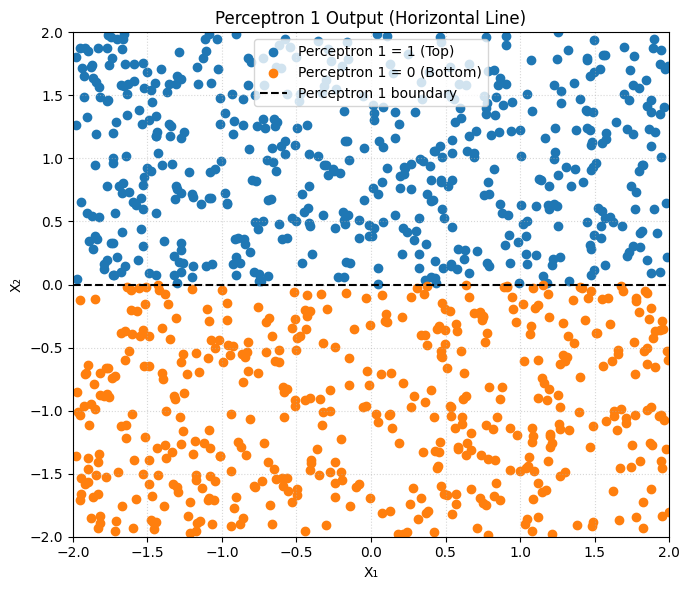

In [ ]:
# Perceptron 1 decision
perceptron_1 = X[:, 1] >= 0
h1 = perceptron_1.astype(float)

plt.figure(figsize=(7, 6))
plt.scatter(
    X[perceptron_1, 0], X[perceptron_1, 1], label="Perceptron 1 = 1 (Top)"
)
plt.scatter(
    X[~perceptron_1, 0], X[~perceptron_1, 1], label="Perceptron 1 = 0 (Bottom)"
)
plt.axhline(0, color="black", linestyle="--", label="Perceptron 1 boundary")

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("X₁")
plt.ylabel("X₂")
plt.title("Perceptron 1 Output (Horizontal Line)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

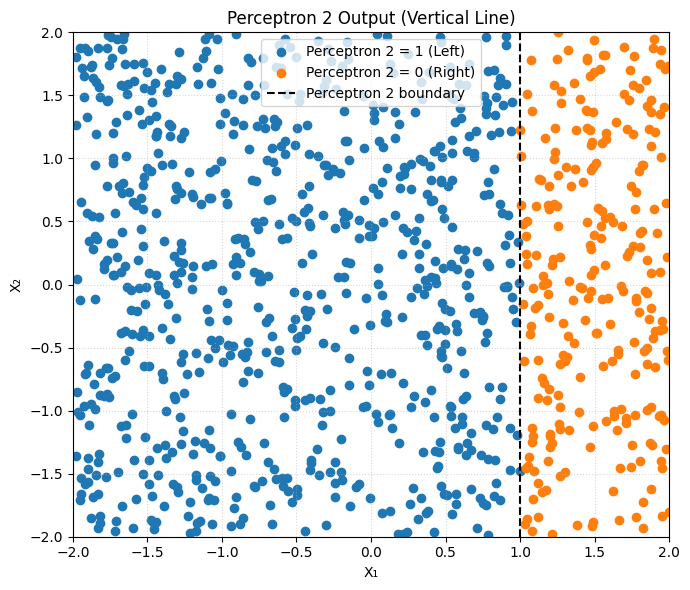

In [ ]:
# Perceptron 2 decision
perceptron_2 = X[:, 0] <= 1
h2 = perceptron_2.astype(float)

plt.figure(figsize=(7, 6))
plt.scatter(
    X[perceptron_2, 0], X[perceptron_2, 1], label="Perceptron 2 = 1 (Left)"
)
plt.scatter(
    X[~perceptron_2, 0], X[~perceptron_2, 1], label="Perceptron 2 = 0 (Right)"
)
plt.axvline(1, color="black", linestyle="--", label="Perceptron 2 boundary")

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel("X₁")
plt.ylabel("X₂")
plt.title("Perceptron 2 Output (Vertical Line)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
print("First perceptron output sample:", h1[:10])
print("Second perceptron output sample:", h2[:10])

combined = h1 + h2
print("\nNaive sum (h1 + h2) sample:", combined[:20])


def sigmoid(z):
  return 1 / (1 + np.exp(-z))


naive_prob = sigmoid(combined)
print(f"Sigmoid(h1 + h2) sample: {naive_prob[:20]}")

First perceptron output sample: [1. 1. 0. 1. 1. 1. 0. 0. 1. 0.]
Second perceptron output sample: [1. 1. 1. 1. 1. 1. 0. 1. 1. 1.]

Naive sum (h1 + h2) sample: [2. 2. 1. 2. 2. 2. 0. 1. 2. 1. 1. 1. 2. 2. 1. 1. 2. 1. 1. 1.]
Sigmoid(h1 + h2) sample: [0.88079708 0.88079708 0.73105858 0.88079708 0.88079708 0.88079708
 0.5        0.73105858 0.88079708 0.73105858 0.73105858 0.73105858
 0.88079708 0.88079708 0.73105858 0.73105858 0.88079708 0.73105858
 0.73105858 0.73105858]


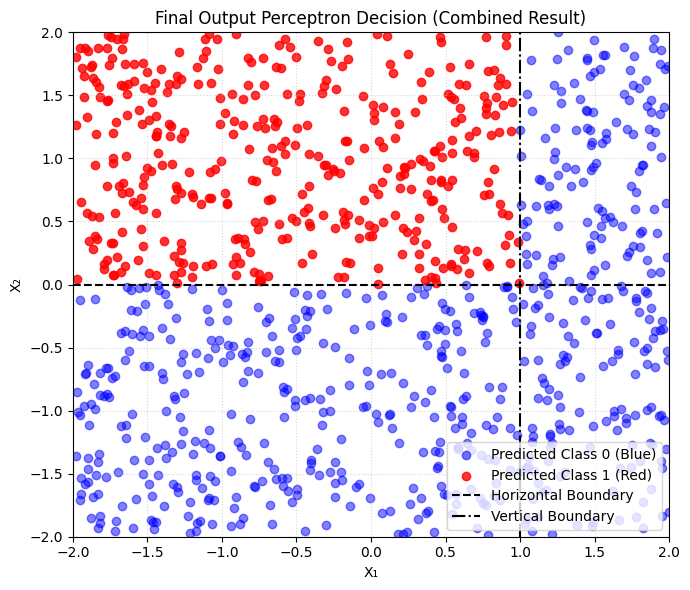

Final Model Accuracy: 100.00%


In [ ]:
# Output Perceptron Weights & Bias (AND Logic)
w1 = 3.0
w2 = 3.0
b = -4.5

# Weighted combination
z = w1 * h1 + w2 * h2 + b
probability = sigmoid(z)
predictions = (probability >= 0.5).astype(int)

# Final Output Visualization
plt.figure(figsize=(7, 6))
plt.scatter(
    X[predictions == 0, 0],
    X[predictions == 0, 1],
    c="blue",
    alpha=0.5,
    label="Predicted Class 0 (Blue)",
)
plt.scatter(
    X[predictions == 1, 0],
    X[predictions == 1, 1],
    c="red",
    alpha=0.8,
    label="Predicted Class 1 (Red)",
)

plt.axhline(0, color="black", linestyle="--", label="Horizontal Boundary")
plt.axvline(1, color="black", linestyle="-.", label="Vertical Boundary")

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.title("Final Output Perceptron Decision (Combined Result)")
plt.xlabel("X₁")
plt.ylabel("X₂")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

# Accuracy check
accuracy = np.mean(predictions == y)
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")

OR

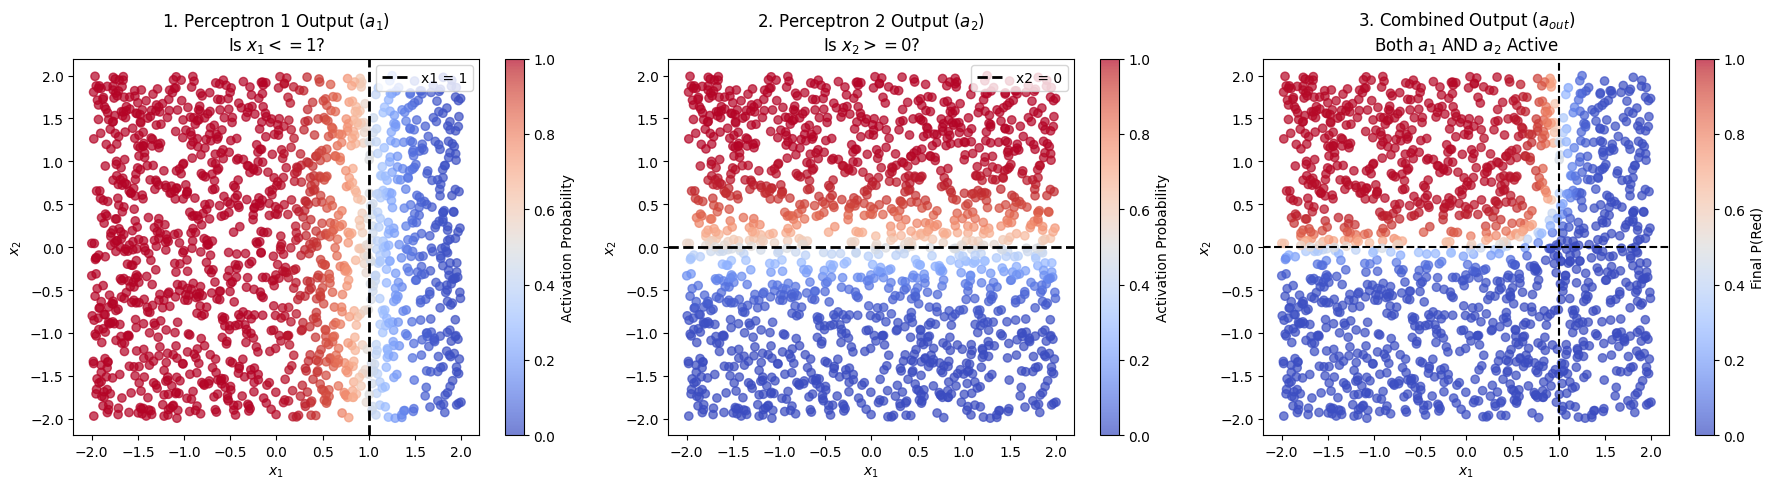

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate Dataset
np.random.seed(42)
n_samples = 1500
X = np.random.uniform(-2, 2, (n_samples, 2))

# Target label: Red (1) ONLY if x2 >= 0 AND x1 <= 1
is_red = (X[:, 1] >= 0) & (X[:, 0] <= 1)
y = np.where(is_red, 1, 0)


# Sigmoid helper
def sigmoid(z):
  return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


# 2. Forward pass through Perceptron 1 (Vertical line at x1 = 1)
w1 = np.array([-5.0, 0.0])
b1 = 5.0
z1 = np.dot(X, w1) + b1
a1 = sigmoid(z1)

# 3. Forward pass through Perceptron 2 (Horizontal line at x2 = 0)
w2 = np.array([0.0, 5.0])
b2 = 0.0
z2 = np.dot(X, w2) + b2
a2 = sigmoid(z2)

# 4. Output Perceptron (AND gate combining a1 and a2)
w_out = np.array([10.0, 10.0])
b_out = -15.0
A_hidden = np.column_stack((a1, a2))
z_out = np.dot(A_hidden, w_out) + b_out
a_out = sigmoid(z_out)

# =========================================================
# PLOTTING THE 3 STAGES
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Perceptron 1 Output (a1)
sc1 = axes[0].scatter(
    X[:, 0], X[:, 1], c=a1, cmap="coolwarm", vmin=0, vmax=1, alpha=0.7
)
axes[0].axvline(1, color="black", linestyle="--", linewidth=2, label="x1 = 1")
axes[0].set_title(
    "1. Perceptron 1 Output ($a_1$)\nIs $x_1 <= 1$?", fontsize=12
)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].legend()
plt.colorbar(sc1, ax=axes[0], label="Activation Probability")

# Plot 2: Perceptron 2 Output (a2)
sc2 = axes[1].scatter(
    X[:, 0], X[:, 1], c=a2, cmap="coolwarm", vmin=0, vmax=1, alpha=0.7
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=2, label="x2 = 0")
axes[1].set_title(
    "2. Perceptron 2 Output ($a_2$)\nIs $x_2 >= 0$?", fontsize=12
)
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].legend()
plt.colorbar(sc2, ax=axes[1], label="Activation Probability")

# Plot 3: Final Output Perceptron (a_out)
sc3 = axes[2].scatter(
    X[:, 0], X[:, 1], c=a_out, cmap="coolwarm", vmin=0, vmax=1, alpha=0.7
)
axes[2].axvline(1, color="black", linestyle="--", linewidth=1.5)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[2].set_title(
    "3. Combined Output ($a_{out}$)\nBoth $a_1$ AND $a_2$ Active", fontsize=12
)
axes[2].set_xlabel("$x_1$")
axes[2].set_ylabel("$x_2$")
plt.colorbar(sc3, ax=axes[2], label="Final P(Red)")

plt.tight_layout()
plt.show()

Writing MLP From scratch

In [ ]:
import numpy as np


class NeuralNetworkMLP:

  def __init__(
      self, input_dim=2, hidden_dim=2, output_dim=1, learning_rate=0.5
  ):
    self.lr = learning_rate

    # Multiply by 2.0 to force stronger, distinct initial gradients
    np.random.seed(10)  # Seed 10 or 100 breaks the symmetry easily!
    self.W1 = np.random.randn(input_dim, hidden_dim) * 2.0
    self.b1 = np.zeros((1, hidden_dim))

    self.W2 = np.random.randn(hidden_dim, output_dim) * 2.0
    self.b2 = np.zeros((1, output_dim))

    self.losses = []

  def _sigmoid(self, z):
    z = np.clip(z, -500, 500)  # Prevent exponential overflow
    return 1.0 / (1.0 + np.exp(-z))

  def _sigmoid_derivative(self, a):
    # Derivative of Sigmoid with respect to its output 'a'
    return a * (1.0 - a)

  def forward(self, X):
    """Computes activations across all layers."""

    # Hidden Layer
    self.Z1 = np.dot(X, self.W1) + self.b1
    self.A1 = self._sigmoid(self.Z1)

    # Output Layer
    self.Z2 = np.dot(self.A1, self.W2) + self.b2
    self.A2 = self._sigmoid(self.Z2)

    return self.A2

  def backward(self, X, y):
    """Computes gradients using the chain rule and updates weights."""
    m = X.shape[0]

    # --- Output Layer Gradients (Binary Cross-Entropy Derivative) ---
    dZ2 = self.A2 - y  # Shape: (m, 1)
    dW2 = (1 / m) * np.dot(self.A1.T, dZ2)  # Shape: (hidden_dim, 1)
    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)  # Shape: (1, 1)

    # --- Hidden Layer Gradients ---
    dA1 = np.dot(dZ2, self.W2.T)  # Shape: (m, hidden_dim)
    dZ1 = dA1 * self._sigmoid_derivative(self.A1)  # Shape: (m, hidden_dim)
    dW1 = (1 / m) * np.dot(X.T, dZ1)  # Shape: (input_dim, hidden_dim)
    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)  # Shape: (1, hidden_dim)

    # --- Parameter Updates ---
    self.W1 -= self.lr * dW1
    self.b1 -= self.lr * db1
    self.W2 -= self.lr * dW2
    self.b2 -= self.lr * db2

  def fit(self, X, y, epochs=10000):
    """Trains the neural network."""
    y = y.reshape(-1, 1)

    for epoch in range(epochs):
      # Forward pass
      y_hat = self.forward(X)

      # Loss calculation (Binary Cross-Entropy)
      epsilon = 1e-15
      y_hat_safe = np.clip(y_hat, epsilon, 1 - epsilon)
      loss = -np.mean(y * np.log(y_hat_safe) + (1 - y) * np.log(1 - y_hat_safe))
      self.losses.append(loss)

      # Backward pass
      self.backward(X, y)

  def predict(self, X, threshold=0.5):
    """Predicts binary classes."""
    y_hat = self.forward(X)
    return (y_hat >= threshold).astype(int)

Solving our old problem

In [ ]:
# XOR Input and Target Output
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

y_xor = np.array([0, 1, 1, 0])

# Initialize and train MLP
mlp = NeuralNetworkMLP(
    input_dim=2, hidden_dim=2, output_dim=1, learning_rate=0.5
)
mlp.fit(X_xor, y_xor, epochs=10000)

# Evaluate
predictions = mlp.predict(X_xor)

print("--- RESULTS ---")
print("Target Output:   ", y_xor)
print("MLP Predictions: ", predictions.flatten())
print(f"Final Loss:      {mlp.losses[-1]:.6f}")
print(f"Accuracy:        {np.mean(predictions.flatten() == y_xor) * 100:.1f}%")

--- RESULTS ---
Target Output:    [0 1 1 0]
MLP Predictions:  [0 1 1 0]
Final Loss:      0.001937
Accuracy:        100.0%


## Forward Pass

$$ \sigma ( \sigma (\sigma (a^{[0]}W^{[1]} + b^{[1]}) W^{[2]} + b^{[2]}) W^{[3]} + b^{[3]} )$$

Where
- $a^{[0]}$ is the output of input layer.
- $a^{[1]}$ is the output of hidden layer 1.
- $a^{[2]}$ is the output of hidden layer 2.
- $a^{[3]}$ is the output of output layer.

Forward Pass

In [ ]:
import numpy as np

# --- 1. ACTIVATION FUNCTIONS & LOSS ---

def relu(z):
    """ReLU activation function: outputs z if z > 0, else 0."""
    return np.maximum(0, z)

def sigmoid(z):
    """Sigmoid activation function: squashes z into range (0, 1)."""
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy_loss(y_hat, y):
    """Computes Binary Cross-Entropy Loss between predictions y_hat and target y."""
    # Clip predictions to prevent log(0) numerical errors
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)

    loss = - (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return np.mean(loss)


# --- 2. THE FORWARD PASS FUNCTION ---

def forward_pass(X, W1, b1, W2, b2):
    """
    Executes a complete 2-layer forward pass.

    Dimensions:
      X : (N, 4) -> N samples, 4 input features
      W1: (4, 3) -> 4 inputs connected to 3 hidden neurons
      b1: (1, 3) -> 1 bias per hidden neuron
      W2: (3, 1) -> 3 hidden inputs connected to 1 output neuron
      b2: (1, 1) -> 1 bias for output neuron
    """
    # ==========================================
    # LAYER 1: Hidden Layer (3 Neurons)
    # ==========================================
    # Step 1.1: Weighted sum (z1 = X * W1 + b1)
    z1 = np.dot(X, W1) + b1          # Shape: (N, 3)

    # Step 1.2: Activation function (a1 = ReLU(z1))
    a1 = relu(z1)                    # Shape: (N, 3)

    # ==========================================
    # LAYER 2: Output Layer (1 Neuron)
    # ==========================================
    # Step 2.1: Weighted sum (z2 = a1 * W2 + b2)
    z2 = np.dot(a1, W2) + b2         # Shape: (N, 1)

    # Step 2.2: Activation function (y_hat = Sigmoid(z2))
    y_hat = sigmoid(z2)              # Shape: (N, 1)

    # Cache intermediate values (critical for Backpropagation later!)
    cache = {
        "z1": z1,
        "a1": a1,
        "z2": z2,
        "y_hat": y_hat
    }

    return y_hat, cache


# --- 3. TEST RUN WITH DUMMY DATA ---

np.random.seed(42)  # For reproducible random numbers

# 1. Synthetic dataset: 2 samples, 4 features each
X = np.array([
    [2100, 3, 15, 5],   # House 1
    [1200, 2, 40, 12]   # House 2
])
y = np.array([[1], [0]]) # True targets (1 = Expensive, 0 = Affordable)

# 2. Initialize weights and biases
W1 = np.random.randn(4, 3) * 0.01  # (4 inputs -> 3 hidden)
b1 = np.zeros((1, 3))              # Biases for hidden layer

W2 = np.random.randn(3, 1) * 0.01  # (3 hidden -> 1 output)
b2 = np.zeros((1, 1))              # Bias for output layer

# 3. Execute Forward Pass
y_hat, cache = forward_pass(X, W1, b1, W2, b2)

# 4. Compute Loss
loss = binary_cross_entropy_loss(y_hat, y)

# --- DISPLAY RESULTS ---
print("--- FORWARD PASS COMPLETED ---")
print(f"Input Matrix X shape:      {X.shape}")
print(f"Hidden Activations (a1):  \n{cache['a1']}")
print(f"Final Predictions (y_hat):\n{y_hat}")
print(f"Computed BCE Loss:        {loss:.6f}")

--- FORWARD PASS COMPLETED ---
Input Matrix X shape:      (2, 4)
Hidden Activations (a1):  
[[10.74069803  0.         13.50072755]
 [ 6.68782276  0.          7.52390239]]
Final Predictions (y_hat):
[[0.4484617 ]
 [0.47163072]]
Computed BCE Loss:        0.719946


📌 Initial Setup & Starting ValuesInputs & TargetInputs: $x_1 = 2$, $x_2 = 3$True Target: $y = 1.0$Learning Rate ($\eta$): $0.1$Initial Weights & BiasesLayer 1 (Hidden Neurons):Neuron 1: $w_{11} = 0.1$, $w_{21} = 0.2$, $b_{11} = 0.1$Neuron 2: $w_{12} = 0.3$, $w_{22} = 0.4$, $b_{12} = 0.2$Layer 2 (Output Neuron):Weights: $w_{21}^{(2)} = 0.5$, $w_{22}^{(2)} = 0.6$Bias: $b_{21} = 0.1$⏩ Step 1: Forward PassCalculate the activations moving forward:Hidden Neuron 1 ($o_{11}$):$$o_{11} = (w_{11} \cdot x_1) + (w_{21} \cdot x_2) + b_{11} = (0.1 \times 2) + (0.2 \times 3) + 0.1 = \mathbf{0.9}$$Hidden Neuron 2 ($o_{12}$):$$o_{12} = (w_{12} \cdot x_1) + (w_{22} \cdot x_2) + b_{12} = (0.3 \times 2) + (0.4 \times 3) + 0.2 = \mathbf{2.0}$$Output Neuron ($o_{21}$):$$o_{21} = (w_{21}^{(2)} \cdot o_{11}) + (w_{22}^{(2)} \cdot o_{12}) + b_{21} = (0.5 \times 0.9) + (0.6 \times 2.0) + 0.1 = \mathbf{1.75}$$Loss Calculation ($L = \frac{1}{2}(o_{21} - y)^2$):$$L = \frac{1}{2} (1.75 - 1.0)^2 = \frac{1}{2} (0.75)^2 = \mathbf{0.28125}$$Current Situation: Our model predicted $1.75$, but the true target is $1.0$. It overpredicted by $0.75$.⏪ Step 2: Backward Pass (Calculating Gradients)A. Output Layer Error & GradientsOutput Error Signal:$$\frac{\partial L}{\partial o_{21}} = o_{21} - y = 1.75 - 1.0 = \mathbf{0.75}$$Gradients for Layer 2 Weights & Bias:$$\frac{\partial L}{\partial w_{21}^{(2)}} = 0.75 \times o_{11} = 0.75 \times 0.9 = \mathbf{0.675}$$$$\frac{\partial L}{\partial w_{22}^{(2)}} = 0.75 \times o_{12} = 0.75 \times 2.0 = \mathbf{1.500}$$$$\frac{\partial L}{\partial b_{21}} = 0.75 \times 1 = \mathbf{0.750}$$B. Flowing Error Back to Hidden LayerCalculate how much error flows back into $o_{11}$ and $o_{12}$:$$\frac{\partial L}{\partial o_{11}} = 0.75 \times w_{21}^{(2)} = 0.75 \times 0.5 = \mathbf{0.375}$$$$\frac{\partial L}{\partial o_{12}} = 0.75 \times w_{22}^{(2)} = 0.75 \times 0.6 = \mathbf{0.450}$$C. Layer 1 GradientsUsing these error signals, find the gradients for Layer 1 weights and biases:Hidden Neuron 1:$$\frac{\partial L}{\partial w_{11}} = 0.375 \times x_1 = 0.375 \times 2 = \mathbf{0.750}$$$$\frac{\partial L}{\partial w_{21}} = 0.375 \times x_2 = 0.375 \times 3 = \mathbf{1.125}$$$$\frac{\partial L}{\partial b_{11}} = 0.375 \times 1 = \mathbf{0.375}$$Hidden Neuron 2:$$\frac{\partial L}{\partial w_{12}} = 0.450 \times x_1 = 0.450 \times 2 = \mathbf{0.900}$$$$\frac{\partial L}{\partial w_{22}} = 0.450 \times x_2 = 0.450 \times 3 = \mathbf{1.350}$$$$\frac{\partial L}{\partial b_{12}} = 0.450 \times 1 = \mathbf{0.450}$$🔄 Step 3: Updating the Weights ($w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial L}{\partial w}$)Using $\eta = 0.1$, update all 9 parameters:Layer 2 Updated Parameters:$w_{21}^{(2)\text{new}} = 0.5 - (0.1 \times 0.675) = \mathbf{0.4325}$$w_{22}^{(2)\text{new}} = 0.6 - (0.1 \times 1.500) = \mathbf{0.4500}$$b_{21}^{\text{new}} = 0.1 - (0.1 \times 0.750) = \mathbf{0.0250}$Layer 1 Updated Parameters:Neuron 1:$w_{11}^{\text{new}} = 0.1 - (0.1 \times 0.750) = \mathbf{0.0250}$$w_{21}^{\text{new}} = 0.2 - (0.1 \times 1.125) = \mathbf{0.0875}$$b_{11}^{\text{new}} = 0.1 - (0.1 \times 0.375) = \mathbf{0.0625}$Neuron 2:$w_{12}^{\text{new}} = 0.3 - (0.1 \times 0.900) = \mathbf{0.2100}$$w_{22}^{\text{new}} = 0.4 - (0.1 \times 1.350) = \mathbf{0.2650}$$b_{12}^{\text{new}} = 0.2 - (0.1 \times 0.450) = \mathbf{0.1550}$🎉 Verification: Did the Network Improve?Let's run a new forward pass using these updated parameters:$o_{11}^{\text{new}} = (0.0250 \times 2) + (0.0875 \times 3) + 0.0625 = \mathbf{0.375}$$o_{12}^{\text{new}} = (0.2100 \times 2) + (0.2650 \times 3) + 0.1550 = \mathbf{1.370}$$o_{21}^{\text{new}} = (0.4325 \times 0.375) + (0.4500 \times 1.370) + 0.0250 = \mathbf{0.8037}$Old Prediction: $1.75$ (Loss: $0.2813$)New Prediction: $0.8037$ (Target was $1.0$)New Loss: $\frac{1}{2}(0.8037 - 1.0)^2 = \mathbf{0.0192}$Notice how the Loss dropped dramatically from $0.2813 \to 0.0192$ after just one single training step!

In [ ]:
import numpy as np

# 1. Setup Data & Learning Rate (N=1 sample)
X  = np.array([[2.0, 3.0]])         # Shape (1, 2) -> [x1, x2]
y  = np.array([[1.0]])              # Shape (1, 1) -> True target
lr = 0.1

# 2. Parameters (Weights grouped by layer)
W1 = np.array([[0.1, 0.3],          # Shape (2, 2) -> [[w11, w12],
               [0.2, 0.4]])         #                  [w21, w22]]
b1 = np.array([[0.1, 0.2]])         # Shape (1, 2) -> [b11, b12]

W2 = np.array([[0.5],               # Shape (2, 1) -> [[w21^(2)],
               [0.6]])              #                  [w22^(2)]]
b2 = np.array([[0.1]])              # Shape (1, 1) -> [b21]

# --- FORWARD PASS ---
A1   = X @ W1 + b1                  # Shape (1, 2) -> Outputs [[0.9, 2.0]]
A2   = A1 @ W2 + b2                 # Shape (1, 1) -> Output  [[1.75]]
loss = 0.5 * np.mean((A2 - y)**2)   # Scalar      -> Loss    0.28125

# --- BACKWARD PASS (VECTORIZED) ---
# Step 1: Output error gradient (dZ2)
dZ2 = A2 - y                        # Shape (1, 1) -> [[0.75]]

# Step 2: Layer 2 parameter gradients (dW2, db2)
dW2 = A1.T @ dZ2                    # Shape (2, 1) -> [[0.675], [1.500]]
db2 = np.sum(dZ2, axis=0, keepdims=True) # Shape (1, 1) -> [[0.750]]

# Step 3: Propagate error backward to Layer 1 activation (dA1)
dA1 = dZ2 @ W2.T                    # Shape (1, 2) -> [[0.375, 0.450]]
dZ1 = dA1                           # Linear derivative is 1.0

# Step 4: Layer 1 parameter gradients (dW1, db1)
dW1 = X.T @ dZ1                     # Shape (2, 2) -> [[0.750, 0.900],
                                    #                  [1.125, 1.350]]
db1 = np.sum(dZ1, axis=0, keepdims=True) # Shape (1, 2) -> [[0.375, 0.450]]

# --- WEIGHT UPDATES ---
W2 -= lr * dW2
b2 -= lr * db2
W1 -= lr * dW1
b1 -= lr * db1

print("Updated W2:\n", W2)
print("Updated W1:\n", W1)

Updated W2:
 [[0.4325]
 [0.45  ]]
Updated W1:
 [[0.025  0.21  ]
 [0.0875 0.265 ]]


In [ ]:
import numpy as np

# 1. Setup Data & Learning Rate
X = np.array([[2.0, 3.0]])  # Shape (1, 2) -> Inputs [x1, x2]
y = np.array([[1.0]])  # Shape (1, 1) -> Target
lr = 0.1
epochs = 100

# 2. Initialize Parameters (Same starting values as before)
W1 = np.array([[0.1, 0.3], [0.2, 0.4]])
b1 = np.array([[0.1, 0.2]])

W2 = np.array([[0.5], [0.6]])
b2 = np.array([[0.1]])

print("--- STARTING TRAINING LOOP ---\n")

for epoch in range(1, epochs + 1):
    # --- FORWARD PASS ---
    A1 = X @ W1 + b1
    A2 = A1 @ W2 + b2
    loss = 0.5 * np.mean((A2 - y) ** 2)

    # --- BACKWARD PASS (VECTORIZED) ---
    dZ2 = A2 - y
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1  # Linear activation derivative = 1.0
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # --- WEIGHT UPDATE ---
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    # Print progression every 10 epochs (and at epoch 1)
    if epoch:
        print(
            f"Epoch {epoch:3d} | Loss: {loss:.8f} | Prediction: {A2[0, 0]:.6f}"
        )

print("\n--- FINAL TEST PREDICTION ---")
final_pred = (X @ W1 + b1) @ W2 + b2
print(f"Target: {y[0,0]} | Final Prediction: {final_pred[0,0]:.6f}")

--- STARTING TRAINING LOOP ---

Epoch   1 | Loss: 0.28125000 | Prediction: 1.750000
Epoch   2 | Loss: 0.01926930 | Prediction: 0.803687
Epoch   3 | Loss: 0.00033304 | Prediction: 0.974191
Epoch   4 | Loss: 0.00000119 | Prediction: 0.998455
Epoch   5 | Loss: 0.00000000 | Prediction: 0.999923
Epoch   6 | Loss: 0.00000000 | Prediction: 0.999996
Epoch   7 | Loss: 0.00000000 | Prediction: 1.000000
Epoch   8 | Loss: 0.00000000 | Prediction: 1.000000
Epoch   9 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  10 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  11 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  12 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  13 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  14 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  15 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  16 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  17 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  18 | Loss: 0.00000000 | Prediction: 1.000000
Epoch  19 | Loss: 0.00000000 | P

## Self Implementation

In [ ]:
import numpy as np

# 1. Structure Dataset (3 samples, 2 features)
# Target formula in your comment: y = 2*x1 + 3*x2 + 5
X = np.array([
    [2, 1],  # Sample 1: x1=2, x2=1 -> y=12
    [5, 7],  # Sample 2: x1=5, x2=7 -> y=36
    [6, 2]   # Sample 3: x1=6, x2=2 -> y=23
])  # Shape: (3, 2)

y = np.array([
    [12],
    [36],
    [23]
])  # Shape: (3, 1)

N = X.shape[0]  # Batch size = 3

# 2. Parameters Initialization
W1 = np.ones((2, 2))   # Shape: (2, 2) -> 2 inputs to 2 hidden neurons
b1 = np.zeros((1, 2))  # Shape: (1, 2)

W2 = np.ones((2, 1))   # Shape: (2, 1) -> 2 hidden neurons to 1 output
b2 = np.zeros((1, 1))  # Shape: (1, 1)

print("--- 1. SHAPE VERIFICATION ---")
print(f"X shape: {X.shape}  | W1 shape: {W1.shape}")
print(f"y shape: {y.shape}  | W2 shape: {W2.shape}\n")

# --- FORWARD PASS ---
A1 = X @ W1 + b1               # (3, 2) @ (2, 2) + (1, 2) -> Shape (3, 2)
A2 = A1 @ W2 + b2              # (3, 2) @ (2, 1) + (1, 1) -> Shape (3, 1)
loss = 0.5 * np.mean((A2 - y) ** 2)

print("--- 2. FORWARD PASS RESULTS ---")
print("A1 (Hidden Output):\n", A1, " | Shape:", A1.shape)
print("A2 (Predictions)  :\n", A2, " | Shape:", A2.shape)
print(f"MSE Loss          : {loss:.4f}\n")

# --- BACKWARD PASS ---
# Derivative of MSE averaged across N=3 samples
dZ2 = (A2 - y) / N             # Shape: (3, 1)

# Layer 2 Gradients
dW2 = A1.T @ dZ2               # (2, 3) @ (3, 1) -> Shape: (2, 1)
db2 = np.sum(dZ2, axis=0, keepdims=True)  # Shape: (1, 1)

# Propagate to Layer 1
dA1 = dZ2 @ W2.T               # (3, 1) @ (1, 2) -> Shape: (3, 2)
dZ1 = dA1                      # Linear activation derivative = 1

# Layer 1 Gradients
dW1 = X.T @ dZ1               # (2, 3) @ (3, 2) -> Shape: (2, 2)
db1 = np.sum(dZ1, axis=0, keepdims=True)  # Shape: (1, 2)

print("--- 3. BACKWARD PASS GRADIENTS ---")
print("dW2:\n", dW2, "\nShape:", dW2.shape)
print("\ndW1:\n", dW1, "\nShape:", dW1.shape)

--- 1. SHAPE VERIFICATION ---
X shape: (3, 2)  | W1 shape: (2, 2)
y shape: (3, 1)  | W2 shape: (2, 1)

--- 2. FORWARD PASS RESULTS ---
A1 (Hidden Output):
 [[ 3.  3.]
 [12. 12.]
 [ 8.  8.]]  | Shape: (3, 2)
A2 (Predictions)  :
 [[ 6.]
 [24.]
 [16.]]  | Shape: (3, 1)
MSE Loss          : 38.1667

--- 3. BACKWARD PASS GRADIENTS ---
dW2:
 [[-72.66666667]
 [-72.66666667]] 
Shape: (2, 1)

dW1:
 [[-38.         -38.        ]
 [-34.66666667 -34.66666667]] 
Shape: (2, 2)


vanishing gradient problem occurs why you backpropagate so to solve this use another function like tanh (which in dense deep network also faces the same problem) or Relu.

you can improve deep learning:
- Droupout layers
- Regularization - we can use both l1 or l2 but most of the time we use l2
- epochs
- number of hidden layers
- number of neuron per layer
- early stopping


# Activation Function


- Sigmoid
- Tanh

 both causes vanishing gradient problem

- Linear

- Relu : it cause dying neuron problem

Variants of Relu:
- Leaky Relu
- Parametric Relu
- ELU
- SELU
  